# 第1弾：ミーンリバージョン戦略（RSI + ボリンジャーバンド）

## 戦略概要
- **ミーンリバージョン（平均回帰）** : 価格が平均から大きく乖離した後、元に戻る傾向を利用
- RSI（相対力指数）で「売られすぎ / 買われすぎ」を検出
- ボリンジャーバンドで「統計的な異常値」を検出
- 両シグナル一致でエントリー

| | 条件 |
|---|---|
| **ロング** | RSI < 30 かつ 終値 < BB下限（-2σ） |
| **ショート** | RSI > 70 かつ 終値 > BB上限（+2σ） |
| **決済** | 価格がBB中央線（SMA）に回帰 |

**検証対象**: USD/JPY（FX）, ETH/JPY（暗号資産）— 5分足

## 1. セットアップ

In [1]:
!pip install japanize-matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 31.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

import japanize_matplotlib

print("ライブラリ読み込み完了")

ライブラリ読み込み完了


## 2. GMO Coin KLine API からデータ取得

GMO Coinは **FX用と暗号資産用でAPIエンドポイントが異なる** ので注意：
- FX（USD_JPY等）: `https://forex-api.coin.z.com/public/v1/klines`（`priceType`パラメータ必要）
- 暗号資産（ETH_JPY等）: `https://api.coin.z.com/public/v1/klines`（`priceType`不要）

In [9]:
# === GMO Coin APIの設定 ===
# FX用と暗号資産用でエンドポイントが異なる
ENDPOINTS = {
    "fx":     "https://forex-api.coin.z.com/public/v1/klines",  # USD_JPY等
    "crypto": "https://api.coin.z.com/public/v1/klines",        # ETH_JPY, BTC_JPY等
}

# シンボルごとにどちらのAPIを使うか定義
SYMBOL_CONFIG = {
    "USD_JPY": {"api": "fx",     "priceType": "BID"},
    "ETH_JPY": {"api": "crypto", "priceType": None},
}

def fetch_gmo_kline(symbol, interval="5min", days_back=365):
    """
    GMO CoinのKLine APIからOHLCVデータを取得。
    シンボルに応じて適切なエンドポイントを自動選択。
    """
    config = SYMBOL_CONFIG.get(symbol)
    if config is None:
        print(f"未定義のシンボル: {symbol}")
        print(f"SYMBOL_CONFIGに追加してください")
        return pd.DataFrame()

    base_url = ENDPOINTS[config["api"]]
    all_data = []
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    current_date = start_date

    print(f"{symbol} の{interval}データを取得中...")
    print(f"API: {config['api']}（{base_url}）")
    print(f"期間: {start_date.strftime('%Y-%m-%d')} → {end_date.strftime('%Y-%m-%d')}")

    request_count = 0
    error_count = 0

    while current_date <= end_date:
        date_str = current_date.strftime("%Y%m%d")

        params = {"symbol": symbol, "interval": interval, "date": date_str}
        if config["priceType"]:
            params["priceType"] = config["priceType"]

        try:
            resp = requests.get(base_url, params=params, timeout=10)
            data = resp.json()

            if data.get("status") == 0 and data.get("data"):
                for c in data["data"]:
                    all_data.append({
                        "datetime": pd.to_datetime(
                            int(c["openTime"]), unit="ms", utc=True
                        ).tz_convert("Asia/Tokyo"),
                        "open":   float(c["open"]),
                        "high":   float(c["high"]),
                        "low":    float(c["low"]),
                        "close":  float(c["close"]),
                        "volume": float(c.get("volume", 0)),
                    })
                request_count += 1
        except Exception as e:
            error_count += 1
            if error_count <= 3:
                print(f"   ⚠️ {date_str}: {e}")

        current_date += timedelta(days=1)

        # レートリミット対策（5リクエストごとに1秒待機）
        if request_count % 5 == 0 and request_count > 0:
            time.sleep(1)

    if not all_data:
        print(f"データ取得失敗。シンボル名を確認: {symbol}")
        return pd.DataFrame()

    df = pd.DataFrame(all_data)
    df = df.sort_values("datetime").drop_duplicates(subset="datetime").reset_index(drop=True)

    print(f"{len(df):,}本取得（{request_count}リクエスト）")
    print(f"最初: {df['datetime'].iloc[0]}")
    print(f"最後: {df['datetime'].iloc[-1]}")
    return df

print("データ取得関数を定義")

データ取得関数を定義


### USD/JPY データ取得

In [10]:
df_usdjpy = fetch_gmo_kline("USD_JPY", interval="5min", days_back=365)
df_usdjpy.head()

USD_JPY の5minデータを取得中...
API: fx（https://forex-api.coin.z.com/public/v1/klines）
期間: 2025-04-05 → 2026-04-05
73,641本取得（258リクエスト）
最初: 2025-04-07 07:00:00+09:00
最後: 2026-04-04 05:55:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-07 07:00:00+09:00,145.494,145.638,144.949,145.132,0.0
1,2025-04-07 07:05:00+09:00,145.139,145.282,144.946,145.118,0.0
2,2025-04-07 07:10:00+09:00,145.118,145.447,145.113,145.346,0.0
3,2025-04-07 07:15:00+09:00,145.346,145.415,145.139,145.263,0.0
4,2025-04-07 07:20:00+09:00,145.261,145.270,145.067,145.239,0.0


### ETH/JPY データ取得

In [11]:
df_eth = fetch_gmo_kline("ETH_JPY", interval="5min", days_back=365)
df_eth.head()

ETH_JPY の5minデータを取得中...
API: crypto（https://api.coin.z.com/public/v1/klines）
期間: 2025-04-05 → 2026-04-05
103,336本取得（366リクエスト）
最初: 2025-04-05 06:00:00+09:00
最後: 2026-04-06 01:20:00+09:00


,datetime,open,high,low,close,volume
0,2025-04-05 06:00:00+09:00,267525.0,267546.0,267044.0,267044.0,6.72
1,2025-04-05 06:05:00+09:00,267019.0,267652.0,267019.0,267652.0,4.28
2,2025-04-05 06:10:00+09:00,267750.0,268098.0,267750.0,267794.0,5.32
3,2025-04-05 06:15:00+09:00,267777.0,267777.0,267136.0,267136.0,10.44
4,2025-04-05 06:20:00+09:00,267242.0,267589.0,267142.0,267348.0,7.58


## 3. テクニカル指標の計算

In [12]:
def calc_rsi(series, period=14):
    """RSIをスクラッチ計算"""
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(alpha=1/period, min_periods=period).mean()
    avg_loss = loss.ewm(alpha=1/period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def calc_bollinger_bands(series, period=20, num_std=2.0):
    """ボリンジャーバンドを計算"""
    sma = series.rolling(window=period).mean()
    std = series.rolling(window=period).std()
    return sma, sma + num_std * std, sma - num_std * std


def add_indicators(df, rsi_period=14, bb_period=20, bb_std=2.0):
    """RSIとBBをDataFrameに追加"""
    df = df.copy()
    df["rsi"] = calc_rsi(df["close"], period=rsi_period)
    df["bb_mid"], df["bb_upper"], df["bb_lower"] = calc_bollinger_bands(
        df["close"], period=bb_period, num_std=bb_std
    )
    return df.dropna().reset_index(drop=True)


df_usdjpy = add_indicators(df_usdjpy)
df_eth    = add_indicators(df_eth)

print(f"USD/JPY: {len(df_usdjpy):,}本")
print(f"ETH/JPY: {len(df_eth):,}本")

USD/JPY: 73,622本
ETH/JPY: 103,317本


## 4. バックテスト

In [13]:
def backtest_mean_reversion(df, rsi_lower=30, rsi_upper=70, spread=0.0, symbol_name=""):
    """ミーンリバージョン戦略のバックテスト（スプレッド考慮あり）"""
    position = 0
    entry_price = 0.0
    entry_time = None
    trades = []
    equity_curve = [0.0]

    for i in range(1, len(df)):
        c  = df["close"].iloc[i]
        r  = df["rsi"].iloc[i]
        bl = df["bb_lower"].iloc[i]
        bu = df["bb_upper"].iloc[i]
        bm = df["bb_mid"].iloc[i]

        if position == 0:
            if r < rsi_lower and c < bl:
                position = 1
                entry_price = c + spread
                entry_time = df["datetime"].iloc[i]
            elif r > rsi_upper and c > bu:
                position = -1
                entry_price = c - spread
                entry_time = df["datetime"].iloc[i]

        elif position == 1 and c >= bm:
            exit_price = c - spread
            trades.append({
                "entry_time": entry_time, "exit_time": df["datetime"].iloc[i],
                "direction": "LONG",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": exit_price - entry_price,
                "pnl_pct": (exit_price - entry_price) / entry_price * 100,
            })
            position = 0

        elif position == -1 and c <= bm:
            exit_price = c + spread
            trades.append({
                "entry_time": entry_time, "exit_time": df["datetime"].iloc[i],
                "direction": "SHORT",
                "entry_price": entry_price, "exit_price": exit_price,
                "pnl": entry_price - exit_price,
                "pnl_pct": (entry_price - exit_price) / entry_price * 100,
            })
            position = 0

        equity_curve.append(sum(t["pnl"] for t in trades))

    if not trades:
        print(f"{symbol_name}: トレード0件")
        return {"trades_df": pd.DataFrame(), "equity_curve": equity_curve, "total_trades": 0}

    tdf = pd.DataFrame(trades)
    wins   = tdf[tdf["pnl"] > 0]
    losses = tdf[tdf["pnl"] <= 0]
    gp = wins["pnl"].sum() if len(wins) else 0
    gl = abs(losses["pnl"].sum()) if len(losses) else 0
    pf = gp / gl if gl > 0 else float("inf")
    eq = pd.Series(equity_curve)
    max_dd = (eq - eq.cummax()).min()
    sharpe = (tdf["pnl_pct"].mean() / tdf["pnl_pct"].std() * np.sqrt(len(tdf))
              if len(tdf) > 1 and tdf["pnl_pct"].std() > 0 else 0.0)
    hold_bars = (tdf["exit_time"] - tdf["entry_time"]).dt.total_seconds() / 300

    res = {
        "symbol": symbol_name, "total_trades": len(tdf),
        "wins": len(wins), "losses": len(losses),
        "win_rate": len(wins) / len(tdf) * 100,
        "total_pnl": tdf["pnl"].sum(), "avg_pnl": tdf["pnl"].mean(),
        "profit_factor": pf, "max_drawdown": max_dd,
        "sharpe_ratio": sharpe, "avg_hold_bars": hold_bars.mean(),
        "trades_df": tdf, "equity_curve": equity_curve,
    }

    print(f"\n{'='*55}")
    print(f"{symbol_name} ミーンリバージョン バックテスト結果")
    print(f"{'='*55}")
    print(f"トレード数      : {res['total_trades']}")
    print(f"勝ち / 負け     : {res['wins']} / {res['losses']}")
    print(f"勝率            : {res['win_rate']:.1f}%")
    print(f"総損益          : {res['total_pnl']:.4f}")
    print(f"平均損益        : {res['avg_pnl']:.4f}")
    print(f"PF              : {res['profit_factor']:.3f}")
    print(f"最大DD          : {res['max_drawdown']:.4f}")
    print(f"シャープレシオ  : {res['sharpe_ratio']:.3f}")
    print(f"平均保有        : {res['avg_hold_bars']:.0f}本（≒{res['avg_hold_bars']*5:.0f}分）")
    print(f"{'='*55}")
    return res

print("バックテスト関数を定義")

バックテスト関数を定義


### USD/JPY バックテスト

In [14]:
# USD/JPY: スプレッド 0.2pips = 0.002円
results_usdjpy = backtest_mean_reversion(
    df_usdjpy, rsi_lower=30, rsi_upper=70,
    spread=0.002, symbol_name="USD/JPY"
)


USD/JPY ミーンリバージョン バックテスト結果
トレード数      : 945
勝ち / 負け     : 581 / 364
勝率            : 61.5%
総損益          : -2.0950
平均損益        : -0.0022
PF              : 0.972
最大DD          : -11.9910
シャープレシオ  : -0.351
平均保有        : 25本（≒127分）


### ETH/JPY バックテスト

In [16]:
# ETH/JPY: スプレッドを価格の0.005%で概算
eth_spread = df_eth["close"].mean() * 0.00005
print(f"ETH/JPY 推定スプレッド: {eth_spread:.0f}円")

results_eth = backtest_mean_reversion(
    df_eth, rsi_lower=30, rsi_upper=70,
    spread=eth_spread, symbol_name="ETH/JPY"
)

ETH/JPY 推定スプレッド: 23円

ETH/JPY ミーンリバージョン バックテスト結果
トレード数      : 1352
勝ち / 負け     : 882 / 470
勝率            : 65.2%
総損益          : -50297.0477
平均損益        : -37.2020
PF              : 0.976
最大DD          : -179620.4094
シャープレシオ  : -0.238
平均保有        : 16本（≒82分）


## 5. 結果の可視化

In [17]:
def plot_results(results, df):
    """4分割チャート + 月別損益"""
    tdf = results["trades_df"]
    if tdf.empty:
        print("トレード0件のためスキップ")
        return
    symbol = results["symbol"]

    fig, axes = plt.subplots(4, 1, figsize=(16, 16),
                             gridspec_kw={"height_ratios": [3, 1, 1, 2]})
    fig.suptitle(f"{symbol} ミーンリバージョン（RSI+BB）", fontsize=16, fontweight="bold")

    # 価格 + BB
    ax = axes[0]
    ax.plot(df["datetime"], df["close"], color="black", lw=0.5, alpha=0.8, label="Close")
    ax.plot(df["datetime"], df["bb_mid"], color="blue", lw=0.5, alpha=0.5, label="BB Mid")
    ax.fill_between(df["datetime"], df["bb_lower"], df["bb_upper"],
                    alpha=0.1, color="blue", label="BB ±2σ")
    longs  = tdf[tdf["direction"] == "LONG"]
    shorts = tdf[tdf["direction"] == "SHORT"]
    if len(longs):
        ax.scatter(longs["entry_time"], longs["entry_price"],
                   marker="^", color="green", s=30, alpha=0.7, label="Long", zorder=5)
    if len(shorts):
        ax.scatter(shorts["entry_time"], shorts["entry_price"],
                   marker="v", color="red", s=30, alpha=0.7, label="Short", zorder=5)
    ax.legend(loc="upper left", fontsize=8); ax.set_ylabel("Price")
    ax.set_title("価格 + ボリンジャーバンド")

    # RSI
    ax = axes[1]
    ax.plot(df["datetime"], df["rsi"], color="purple", lw=0.5)
    ax.axhline(70, color="red", ls="--", alpha=0.5, lw=0.5)
    ax.axhline(30, color="green", ls="--", alpha=0.5, lw=0.5)
    ax.fill_between(df["datetime"], 30, 70, alpha=0.05, color="gray")
    ax.set_ylabel("RSI"); ax.set_ylim(0, 100); ax.set_title("RSI（14）")

    # 各トレードPnL
    ax = axes[2]
    colors = ["green" if p > 0 else "red" for p in tdf["pnl"]]
    ax.bar(range(len(tdf)), tdf["pnl"], color=colors, alpha=0.7)
    ax.axhline(0, color="black", lw=0.5)
    ax.set_ylabel("PnL"); ax.set_xlabel("Trade #"); ax.set_title("各トレード損益")

    # エクイティカーブ
    ax = axes[3]
    eq = results["equity_curve"]
    ax.plot(eq, color="navy", lw=1)
    ax.fill_between(range(len(eq)), eq, alpha=0.1, color="navy")
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_ylabel("累積損益"); ax.set_xlabel("Bar"); ax.set_title("エクイティカーブ")

    plt.tight_layout(); plt.show()

    # 月別損益
    tdf2 = tdf.copy()
    tdf2["month"] = tdf2["entry_time"].dt.to_period("M")
    monthly = tdf2.groupby("month")["pnl"].sum()
    if len(monthly) > 1:
        fig2, ax2 = plt.subplots(figsize=(14, 3))
        mc = ["green" if v > 0 else "red" for v in monthly.values]
        ax2.bar(range(len(monthly)), monthly.values, color=mc, alpha=0.7)
        ax2.set_xticks(range(len(monthly)))
        ax2.set_xticklabels([str(m) for m in monthly.index], rotation=45, fontsize=8)
        ax2.axhline(0, color="black", lw=0.5)
        ax2.set_title(f"{symbol} 月別損益"); ax2.set_ylabel("PnL")
        plt.tight_layout(); plt.show()

print("可視化関数を定義")

可視化関数を定義


### USD/JPY 結果

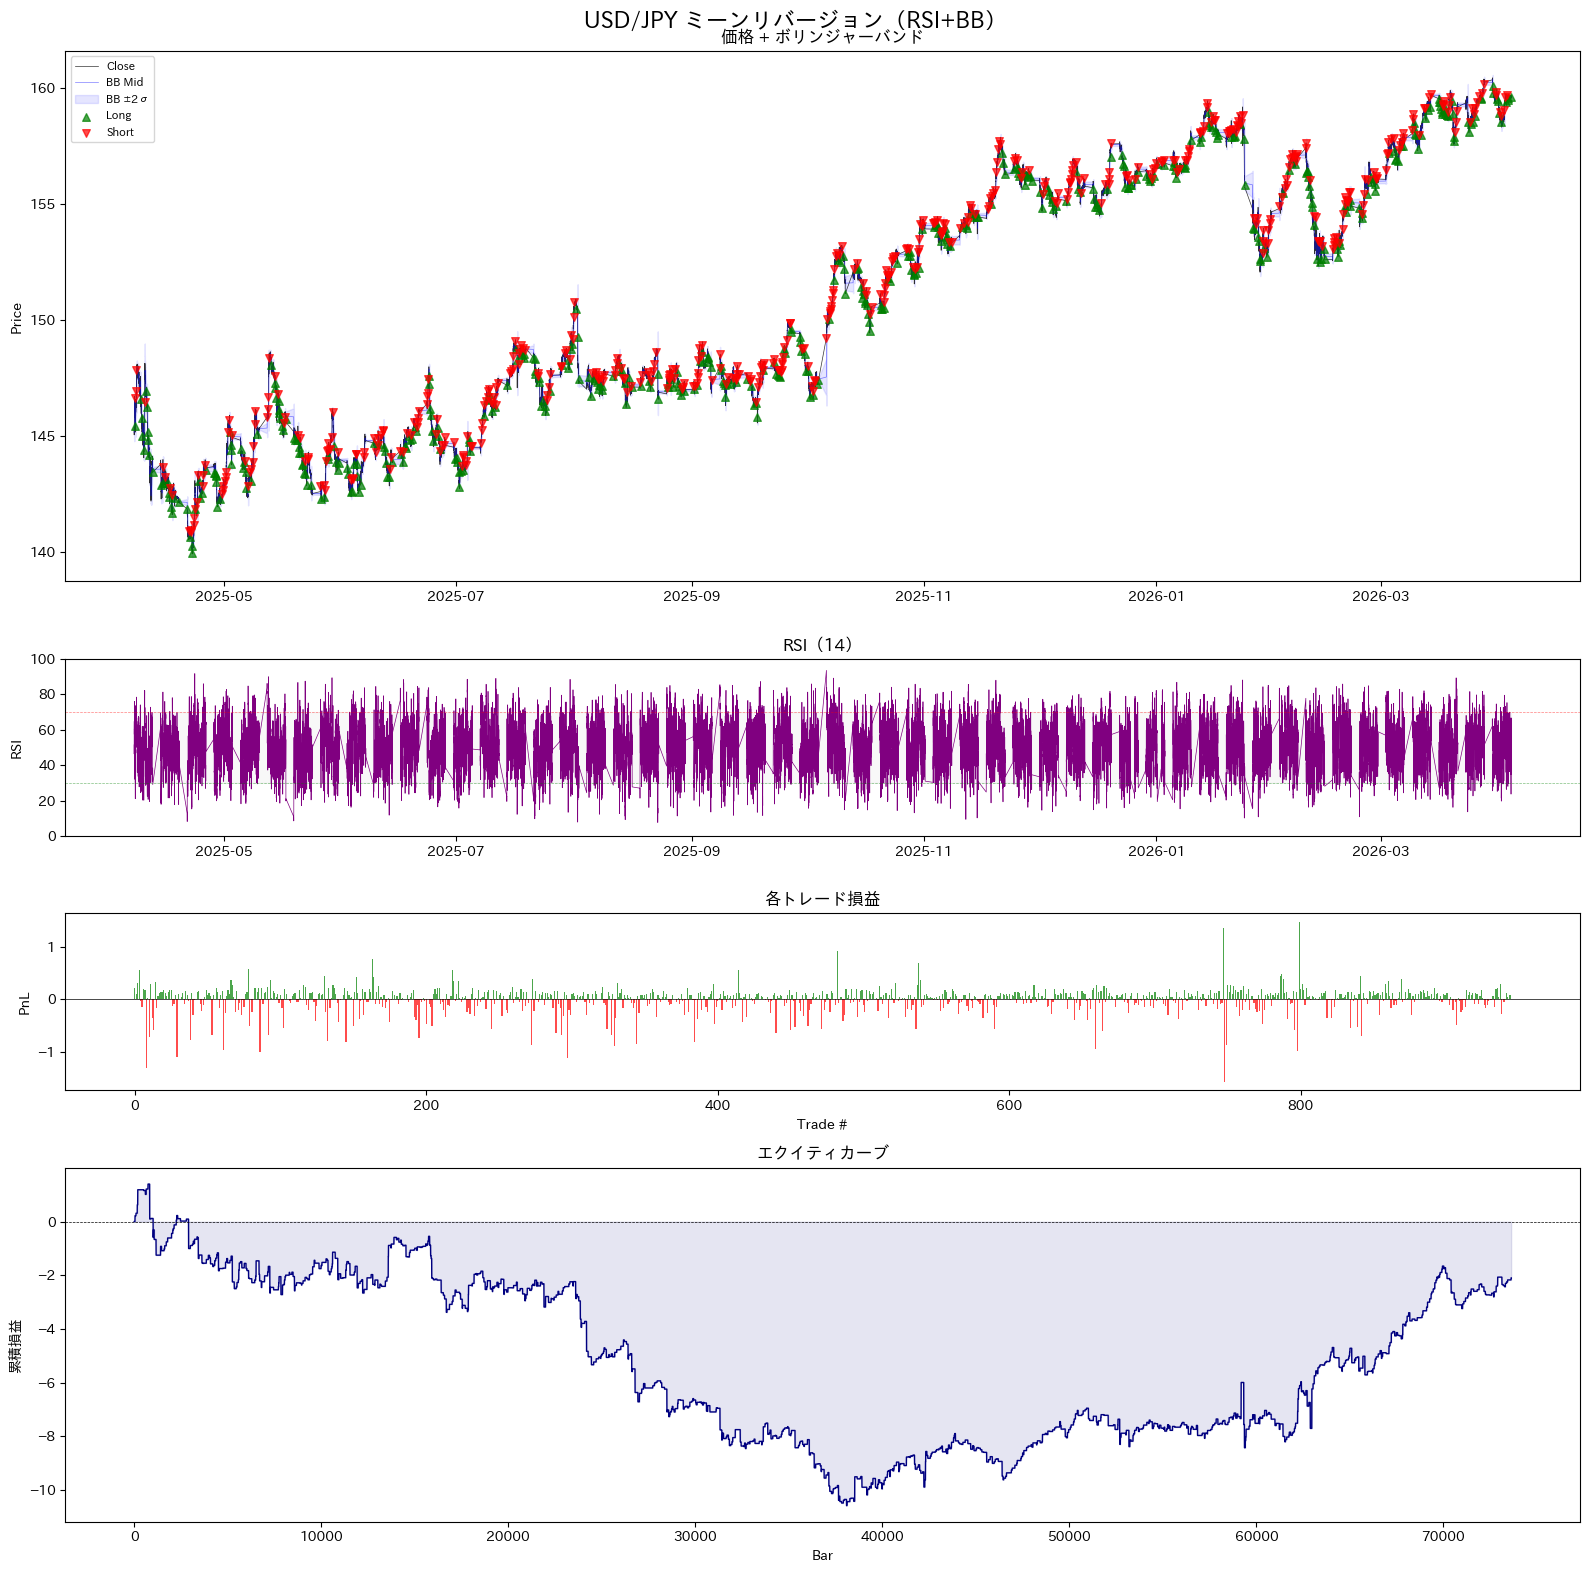

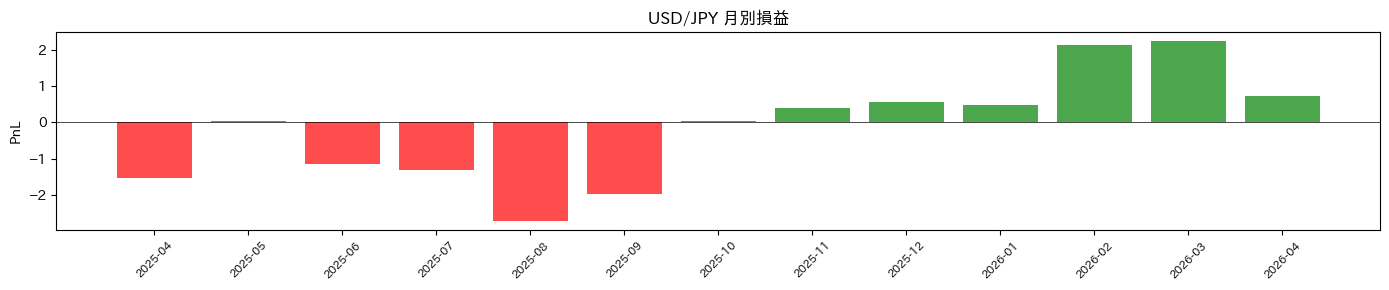

In [18]:
plot_results(results_usdjpy, df_usdjpy)

### ETH/JPY 結果

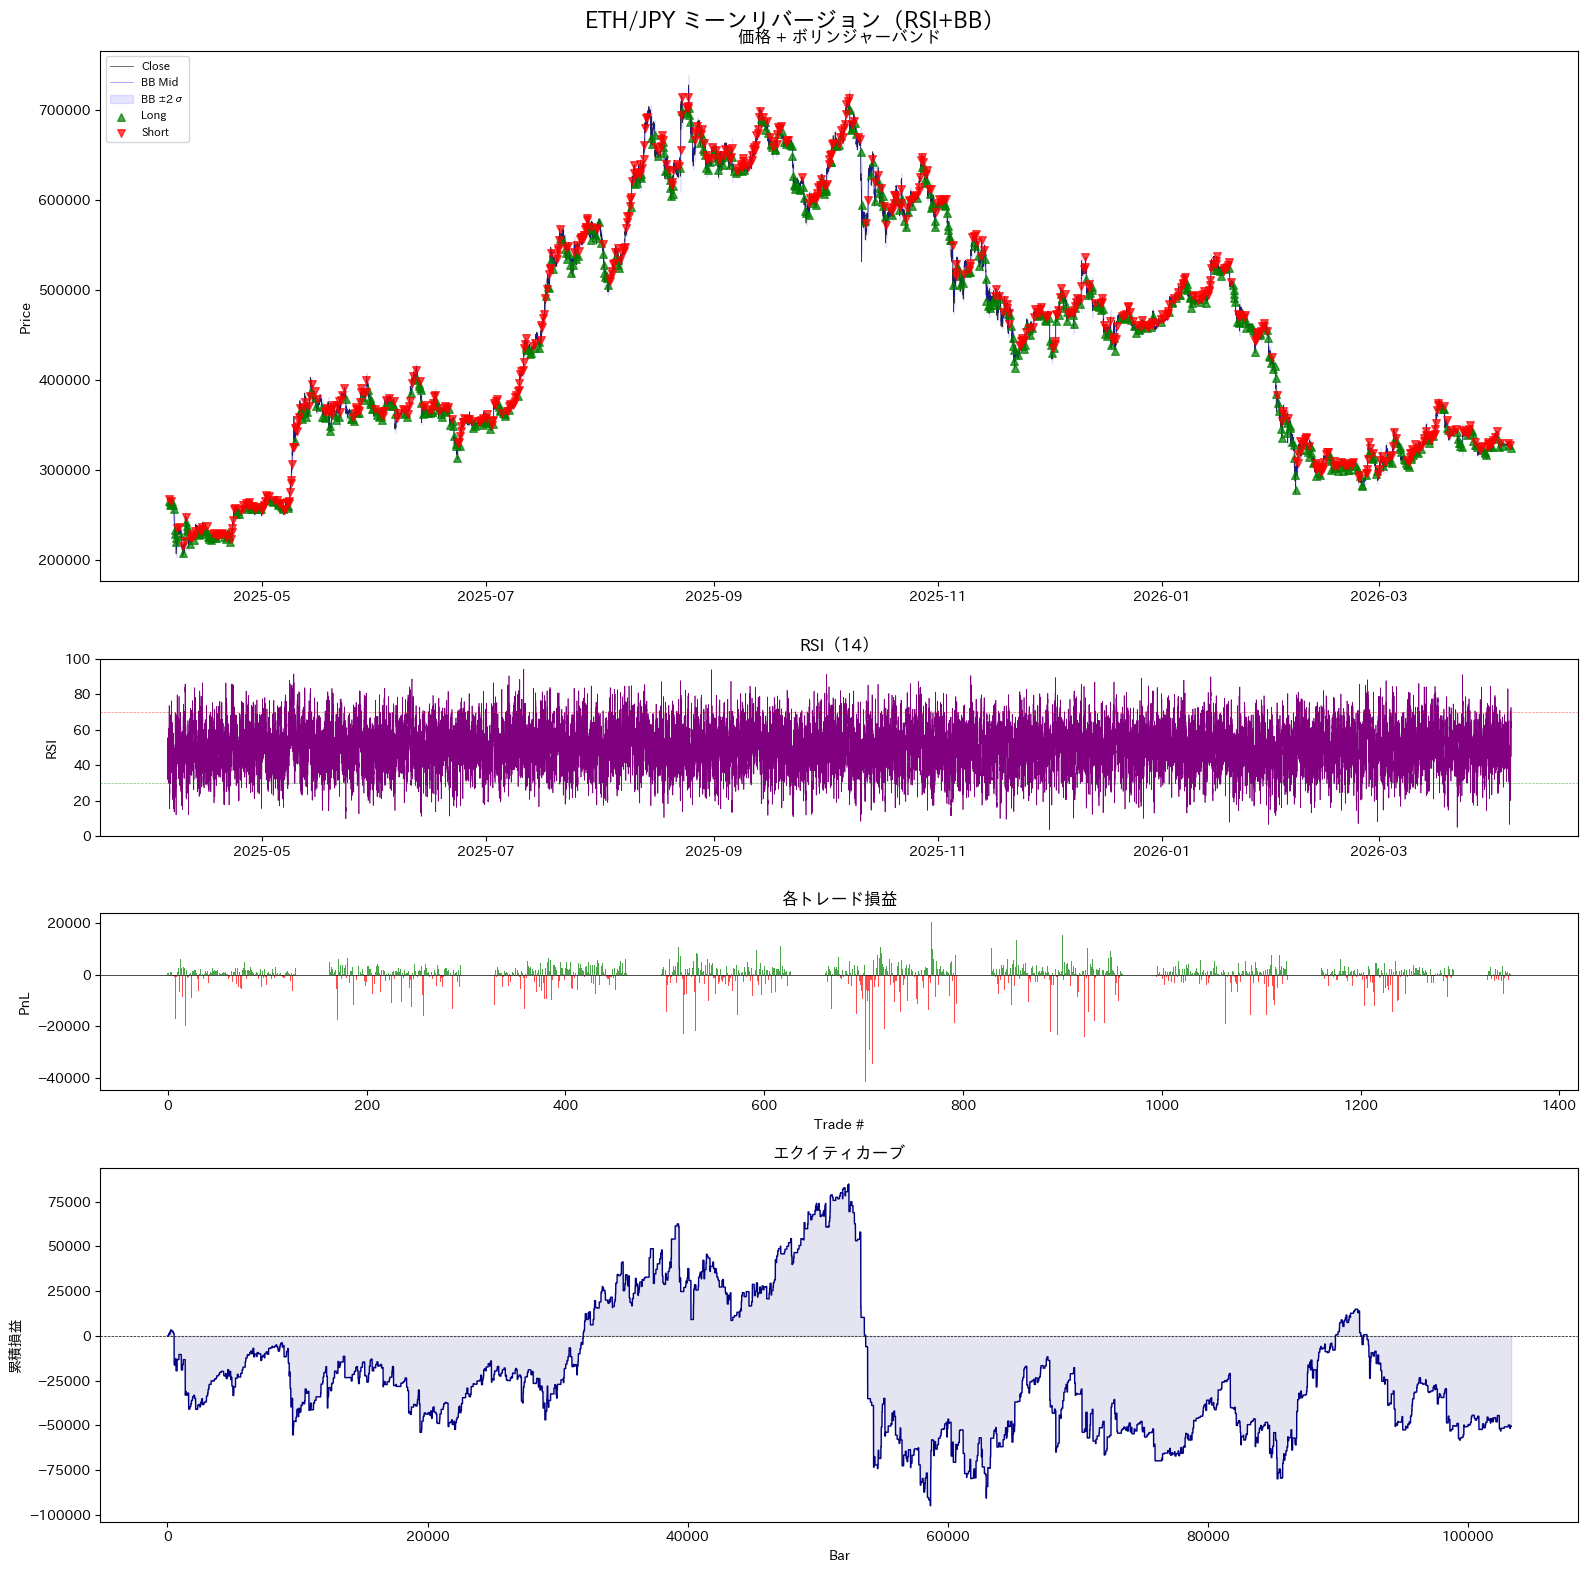

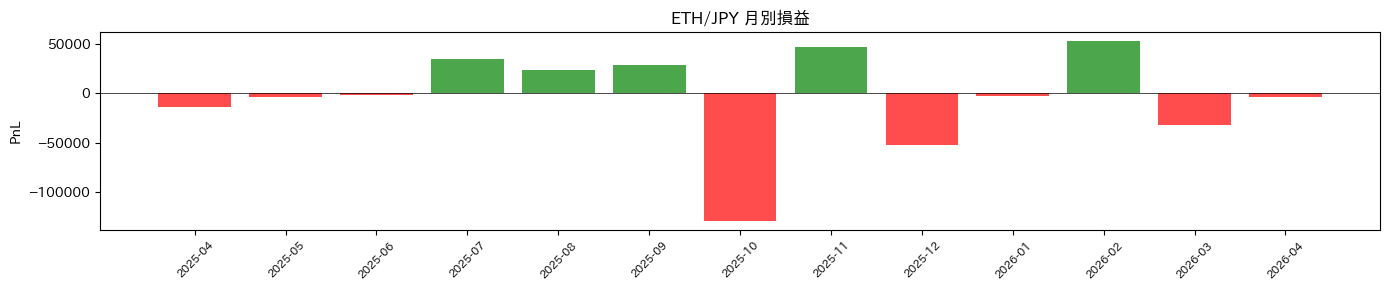

In [19]:
plot_results(results_eth, df_eth)

## 6. パラメータ感度分析

In [26]:
def parameter_sensitivity(df, symbol_name, spread):
    """RSI閾値 × BB期間 × BB σ の感度分析（64パターン）"""
    rows = []
    rsi_pairs  = [(20, 80), (25, 75), (30, 70), (35, 65)]
    bb_periods = [15, 20, 25, 30]
    bb_stds    = [1.5, 2.0, 2.5, 3.0]
    total = len(rsi_pairs) * len(bb_periods) * len(bb_stds)

    print(f"{symbol_name} 感度分析中...（{total}パターン）")

    for rsi_lo, rsi_hi in rsi_pairs:
        for bbp in bb_periods:
            for bbs in bb_stds:
                tmp = df.copy()
                tmp["rsi"] = calc_rsi(tmp["close"], 14)
                tmp["bb_mid"], tmp["bb_upper"], tmp["bb_lower"] = calc_bollinger_bands(
                    tmp["close"], bbp, bbs)
                tmp = tmp.dropna().reset_index(drop=True)

                pos = 0; ep = 0.0; pnls = []
                for i in range(1, len(tmp)):
                    c = tmp["close"].iloc[i]; r = tmp["rsi"].iloc[i]
                    bl = tmp["bb_lower"].iloc[i]; bu = tmp["bb_upper"].iloc[i]
                    bm = tmp["bb_mid"].iloc[i]

                    if pos == 0:
                        if r < rsi_lo and c < bl:   pos = 1;  ep = c + spread
                        elif r > rsi_hi and c > bu: pos = -1; ep = c - spread
                    elif pos == 1 and c >= bm:
                        pnls.append((c - spread) - ep); pos = 0
                    elif pos == -1 and c <= bm:
                        pnls.append(ep - (c + spread)); pos = 0

                if pnls:
                    arr = np.array(pnls)
                    w = arr[arr > 0]; l = arr[arr <= 0]
                    gp = w.sum() if len(w) else 0
                    gl = abs(l.sum()) if len(l) else 0
                    rows.append({
                        "RSI": f"{rsi_lo}/{rsi_hi}", "BB期間": bbp, "BB_σ": bbs,
                        "トレード数": len(pnls),
                        "勝率%": round(len(w)/len(pnls)*100, 1),
                        "総損益": round(arr.sum(), 4),
                        "PF": round(gp/gl, 3) if gl > 0 else 0,
                    })

    grid = pd.DataFrame(rows).sort_values("PF", ascending=False)
    print(f"\n{symbol_name} TOP10（PF順）:")
    display(grid.head(10))

    filtered = grid[grid["トレード数"] >= 10].copy()
    if len(filtered):
        print(f"\n{symbol_name} TOP10（トレード数≥10, PF順）:")
        display(filtered.head(10))
    return grid

print("感度分析関数を定義")

感度分析関数を定義


### USD/JPY 感度分析

In [27]:
grid_usdjpy = parameter_sensitivity(df_usdjpy, "USD/JPY", spread=0.002)

USD/JPY 感度分析中...（64パターン）

USD/JPY TOP10（PF順）:


,RSI,BB期間,BB_σ,トレード数,勝率%,総損益,PF
7,20/80,20,3.0,58,62.1,0.307,1.036
21,25/75,20,2.0,466,63.7,1.372,1.034
17,25/75,15,2.0,442,62.9,0.651,1.019
50,35/65,15,2.5,794,63.0,-0.378,0.993
34,30/70,15,2.5,444,61.5,-0.480,0.988
56,35/65,25,1.5,1808,64.6,-1.687,0.987
5,20/80,20,2.0,179,58.7,-0.260,0.986
20,25/75,20,1.5,548,61.7,-0.823,0.982
54,35/65,20,2.5,971,62.8,-1.418,0.981
11,20/80,25,3.0,75,62.7,-0.255,0.977



USD/JPY TOP10（トレード数≥10, PF順）:


,RSI,BB期間,BB_σ,トレード数,勝率%,総損益,PF
7,20/80,20,3.0,58,62.1,0.307,1.036
21,25/75,20,2.0,466,63.7,1.372,1.034
17,25/75,15,2.0,442,62.9,0.651,1.019
50,35/65,15,2.5,794,63.0,-0.378,0.993
34,30/70,15,2.5,444,61.5,-0.480,0.988
56,35/65,25,1.5,1808,64.6,-1.687,0.987
5,20/80,20,2.0,179,58.7,-0.260,0.986
20,25/75,20,1.5,548,61.7,-0.823,0.982
54,35/65,20,2.5,971,62.8,-1.418,0.981
11,20/80,25,3.0,75,62.7,-0.255,0.977


### ETH/JPY 感度分析

In [28]:
eth_spread = df_eth["close"].mean() * 0.00005
grid_eth = parameter_sensitivity(df_eth, "ETH/JPY", spread=eth_spread)

ETH/JPY 感度分析中...（64パターン）

ETH/JPY TOP10（PF順）:


,RSI,BB期間,BB_σ,トレード数,勝率%,総損益,PF
49,35/65,15,2.0,2450,67.4,263325.9580,1.090
48,35/65,15,1.5,2889,68.4,280766.2280,1.086
62,35/65,30,2.5,1566,68.3,147579.4507,1.057
58,35/65,25,2.5,1623,67.3,105309.1395,1.042
52,35/65,20,1.5,2605,67.9,118249.4451,1.035
53,35/65,20,2.0,2349,67.7,83989.1761,1.027
56,35/65,25,1.5,2419,67.5,53732.4606,1.016
61,35/65,30,2.0,2100,67.7,51399.5354,1.016
21,25/75,20,2.0,694,63.5,17181.8779,1.014
55,35/65,20,3.0,696,64.5,15474.2003,1.014



ETH/JPY TOP10（トレード数≥10, PF順）:


,RSI,BB期間,BB_σ,トレード数,勝率%,総損益,PF
49,35/65,15,2.0,2450,67.4,263325.9580,1.090
48,35/65,15,1.5,2889,68.4,280766.2280,1.086
62,35/65,30,2.5,1566,68.3,147579.4507,1.057
58,35/65,25,2.5,1623,67.3,105309.1395,1.042
52,35/65,20,1.5,2605,67.9,118249.4451,1.035
53,35/65,20,2.0,2349,67.7,83989.1761,1.027
56,35/65,25,1.5,2419,67.5,53732.4606,1.016
61,35/65,30,2.0,2100,67.7,51399.5354,1.016
21,25/75,20,2.0,694,63.5,17181.8779,1.014
55,35/65,20,3.0,696,64.5,15474.2003,1.014


## 7. 比較サマリー

In [31]:
# === デフォルト vs 感度分析TOP の比較 ===

def get_best_params(grid, min_trades=10):
    """感度分析結果からトレード数フィルタ付きでベストパラメータを取得"""
    filtered = grid[grid["トレード数"] >= min_trades]
    if len(filtered) == 0:
        return None
    return filtered.iloc[0]  # PF降順でソート済みなのでiloc[0]がTOP

best_usdjpy = get_best_params(grid_usdjpy)
best_eth    = get_best_params(grid_eth)

rows = []

# USD/JPY
rows.append({
    "通貨ペア": "USD/JPY", "条件": "デフォルト（RSI 30/70, BB20, 2σ）",
    "トレード数": results_usdjpy["total_trades"],
    "勝率%": round(results_usdjpy["win_rate"], 1),
    "総損益": round(results_usdjpy["total_pnl"], 4),
    "PF": round(results_usdjpy["profit_factor"], 3),
    "最大DD": round(results_usdjpy["max_drawdown"], 4),
})
if best_usdjpy is not None:
    rows.append({
        "通貨ペア": "USD/JPY", "条件": f"最適化（RSI {best_usdjpy['RSI']}, BB{best_usdjpy['BB期間']}, {best_usdjpy['BB_σ']}σ）",
        "トレード数": best_usdjpy["トレード数"],
        "勝率%": best_usdjpy["勝率%"],
        "総損益": best_usdjpy["総損益"],
        "PF": best_usdjpy["PF"],
        "最大DD": "-",
    })

# ETH/JPY
rows.append({
    "通貨ペア": "ETH/JPY", "条件": "デフォルト（RSI 30/70, BB20, 2σ）",
    "トレード数": results_eth["total_trades"],
    "勝率%": round(results_eth["win_rate"], 1),
    "総損益": round(results_eth["total_pnl"], 4),
    "PF": round(results_eth["profit_factor"], 3),
    "最大DD": round(results_eth["max_drawdown"], 4),
})
if best_eth is not None:
    rows.append({
        "通貨ペア": "ETH/JPY", "条件": f"最適化（RSI {best_eth['RSI']}, BB{best_eth['BB期間']}, {best_eth['BB_σ']}σ）",
        "トレード数": best_eth["トレード数"],
        "勝率%": best_eth["勝率%"],
        "総損益": best_eth["総損益"],
        "PF": best_eth["PF"],
        "最大DD": "-",
    })

print("=" * 75)
print("ミーンリバージョン戦略 最終比較（5分足）")
print("デフォルトパラメータ vs 感度分析ベスト（トレード数≥10）")
print("=" * 75)
display(pd.DataFrame(rows))
print()
print("最適化パラメータはin-sampleの結果。")

ミーンリバージョン戦略 最終比較（5分足）
デフォルトパラメータ vs 感度分析ベスト（トレード数≥10）


,通貨ペア,条件,トレード数,勝率%,総損益,PF,最大DD
0,USD/JPY,"デフォルト（RSI 30/70, BB20, 2σ）",945,61.5,-2.0950,0.972,-11.991
1,USD/JPY,"最適化（RSI 20/80, BB20, 3.0σ）",58,62.1,0.3070,1.036,-
2,ETH/JPY,"デフォルト（RSI 30/70, BB20, 2σ）",1352,65.2,-50297.0477,0.976,-179620.4094
3,ETH/JPY,"最適化（RSI 35/65, BB15, 2.0σ）",2450,67.4,263325.9580,1.090,-



最適化パラメータはin-sampleの結果。
